In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

In [4]:
data = {
    'Stellar Type': ['M0V', 'M1V', 'M2V', 'M3V', 'M4V', 'M5V', 'M6V', 'K0V', 'K1V', 'K2V', 'K3V', 'K4V', 'K5V', 'K6V', 'K7V', 'K8V', 'K9V',
                     'G0V', 'G1V', 'G2V', 'G3V', 'G4V', 'G5V', 'G6V', 'G7V', 'G8V', 'G9V',
                     'F0V', 'F1V', 'F2V', 'F3V', 'F4V', 'F5V', 'F6V', 'F7V', 'F8V', 'F9V'],
    'Mass': [0.57, 0.50, 0.44, 0.37, 0.23, 0.162, 0.102, 0.88, 0.86, 0.82, 0.78, 0.73, 0.70, 0.69, 0.64, 0.62, 0.59,
             1.06, 1.03, 1.00, 0.99, 0.985, 0.98, 0.97, 0.95, 0.94, 0.90,
             1.61, 1.50, 1.46, 1.44, 1.38, 1.33, 1.25, 1.21, 1.18, 1.13],
    'Radius': [0.588, 0.501, 0.446, 0.361, 0.274, 0.196, 0.137, 0.813, 0.797, 0.783, 0.755, 0.713, 0.701, 0.669, 0.630, 0.615, 0.608,
               1.100, 1.060, 1.012, 1.002, 0.991, 0.977, 0.949, 0.927, 0.914, 0.853,
               1.728, 1.679, 1.622, 1.578, 1.533, 1.473, 1.359, 1.324, 1.221, 1.167],
    'Luminosity': [0.069, 0.041, 0.029, 0.016, 7.2e-3, 3.0e-3, 1.0e-3, 0.46, 0.41, 0.37, 0.28, 0.20, 0.17, 0.14, 0.10, 0.087, 0.079,
                   1.35, 1.20, 1.02, 0.98, 0.91, 0.89, 0.79, 0.74, 0.68, 0.55,
                   7.24, 6.17, 5.13, 4.68, 4.17, 3.63, 2.69, 2.45, 1.95, 1.66],
    'Effective Temperature': [3850, 3660, 3560, 3430, 3210, 3060, 2810, 5270, 5170, 5100, 4830, 4600, 4440, 4300, 4100, 3990, 3930,
                              5930, 5860, 5770, 5720, 5680, 5660, 5600, 5550, 5480, 5380,
                              7220, 7020, 6820, 6750, 6670, 6550, 6350, 6280, 6180, 6050],
    'B-V Index': [1.42, 1.49, 1.51, 1.53, 1.65, 1.83, 2.01, 0.82, 0.86, 0.88, 0.99, 1.09, 1.15, 1.24, 1.34, 1.36, 1.40,
                  0.60, 0.62, 0.65, 0.66, 0.67, 0.68, 0.70, 0.71, 0.73, 0.78,
                  0.30, 0.33, 0.37, 0.39, 0.41, 0.44, 0.49, 0.50, 0.53, 0.56]
}
data['4% Dust Mass'] = [mass * 0.04 for mass in data['Mass']]
data['1/R^2'] = [1 / (radius ** 2) for radius in data['Radius']]

stellar_df = pd.DataFrame(data)
stellar_df = stellar_df.sort_values(by='Effective Temperature', ascending=True)
print(stellar_df)

mean_median_df = pd.read_csv('mean_median_data.csv')
print(mean_median_df)

mean_median_df['Teff Range Average'] = mean_median_df['Teff Range'].apply(
    lambda x: sum(map(int, x.replace('K', '').split('-'))) / 2
)
print(mean_median_df)

   Stellar Type   Mass  Radius  Luminosity  Effective Temperature  B-V Index  \
6           M6V  0.102   0.137      0.0010                   2810       2.01   
5           M5V  0.162   0.196      0.0030                   3060       1.83   
4           M4V  0.230   0.274      0.0072                   3210       1.65   
3           M3V  0.370   0.361      0.0160                   3430       1.53   
2           M2V  0.440   0.446      0.0290                   3560       1.51   
1           M1V  0.500   0.501      0.0410                   3660       1.49   
0           M0V  0.570   0.588      0.0690                   3850       1.42   
16          K9V  0.590   0.608      0.0790                   3930       1.40   
15          K8V  0.620   0.615      0.0870                   3990       1.36   
14          K7V  0.640   0.630      0.1000                   4100       1.34   
13          K6V  0.690   0.669      0.1400                   4300       1.24   
12          K5V  0.700   0.701      0.17

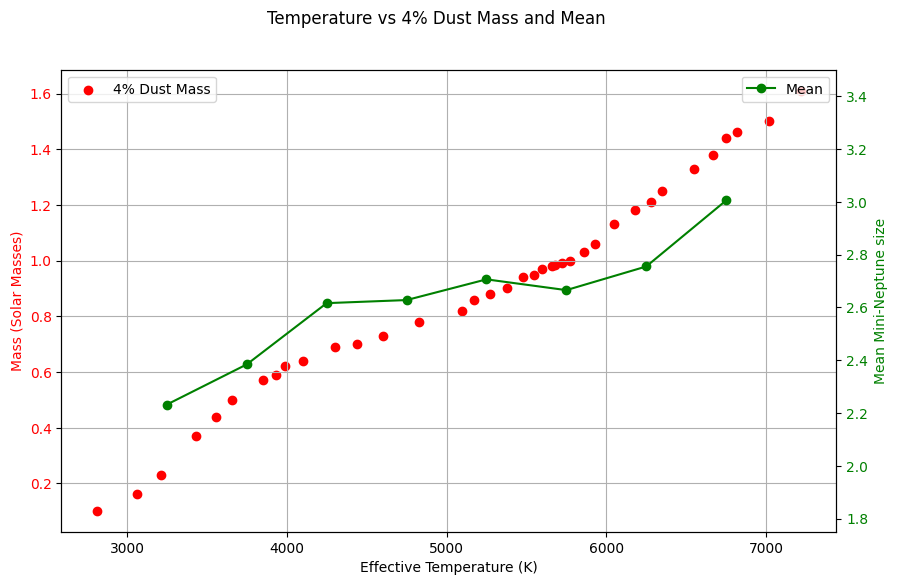

In [31]:
fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot 4% Dust Mass on the primary y-axis
ax1.scatter(stellar_df['Effective Temperature'], stellar_df['Mass'], color='r', label='4% Dust Mass')
ax1.set_xlabel('Effective Temperature (K)')
ax1.set_ylabel('Mass (Solar Masses)', color='r')
ax1.tick_params(axis='y', labelcolor='r')
ax1.grid(True)

# Create a secondary y-axis for Mean
ax2 = ax1.twinx()
ax2.plot(mean_median_df['Teff Range Average'], mean_median_df['Mean'], color='g', label='Mean', marker='o', linestyle='-')
ax2.set_ylabel('Mean Mini-Neptune size', color='g')
ax2.tick_params(axis='y', labelcolor='g')
ax2.set_ylim(1.75, 3.5)

# Add a title and legend
fig.suptitle('Temperature vs 4% Dust Mass and Mean')
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')

plt.show()



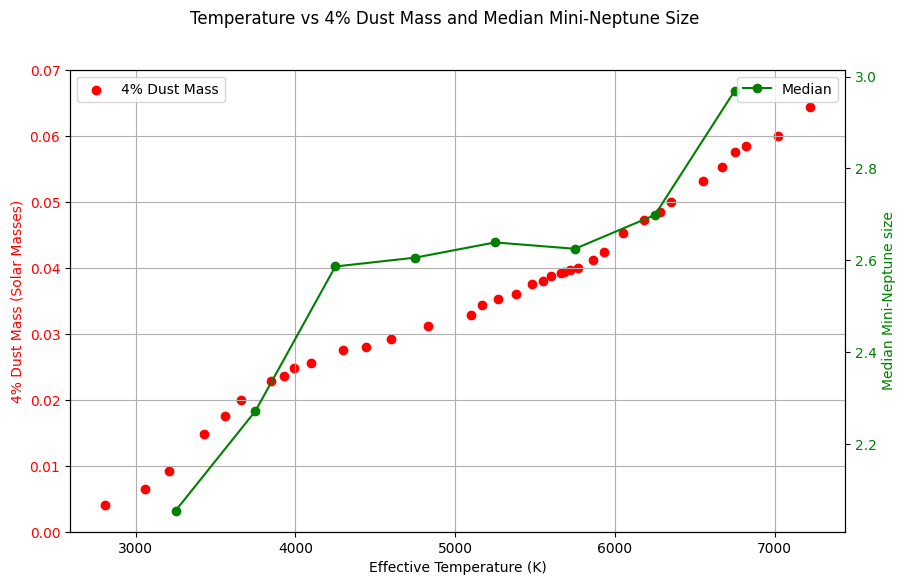

In [6]:
fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot 4% Dust Mass on the primary y-axis
ax1.scatter(stellar_df['Effective Temperature'], stellar_df['4% Dust Mass'], color='r', label='4% Dust Mass')
ax1.set_xlabel('Effective Temperature (K)')
ax1.set_ylabel('4% Dust Mass (Solar Masses)', color='r')
ax1.tick_params(axis='y', labelcolor='r')
ax1.grid(True)
ax1.set_ylim(-.00,.07)
#ax1.set_ylim(-.01,.0)

# Create a secondary y-axis for Mean
ax2 = ax1.twinx()
ax2.plot(mean_median_df['Teff Range Average'], mean_median_df['Median'], color='g', label='Median', marker='o', linestyle='-')
ax2.set_ylabel('Median Mini-Neptune size', color='g')
ax2.tick_params(axis='y', labelcolor='g')
#ax2.set_ylim(-.5,6.5)

# Add a title and legend
fig.suptitle('Temperature vs 4% Dust Mass and Median Mini-Neptune Size')
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')

plt.show()
#mass to radius relationship roughly 1/4 because geometry and gravity
#!can take a model of for a given amount of hydrogen what's the radius of the planet, take planet and get how much hydrogen that would be proportional to, then compare to stellar mass
#!mini-neptune observational mass radius relationship, do for a rocky planet as well

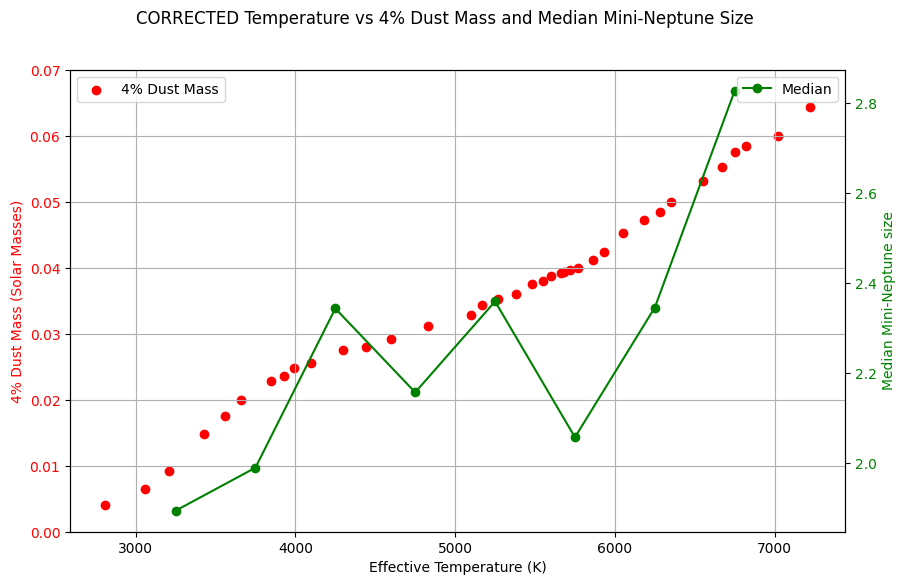

In [7]:
fig, ax1 = plt.subplots(figsize=(10, 6))

corrected_mean_median_df = pd.read_csv('corrected_medians.csv')
corrected_mean_median_df['Teff Range Average'] = corrected_mean_median_df['Teff Range'].apply(
    lambda x: sum(map(int, x.replace('K', '').split('-'))) / 2
)


# Plot 4% Dust Mass on the primary y-axis
ax1.scatter(stellar_df['Effective Temperature'], stellar_df['4% Dust Mass'], color='r', label='4% Dust Mass')
ax1.set_xlabel('Effective Temperature (K)')
ax1.set_ylabel('4% Dust Mass (Solar Masses)', color='r')
ax1.tick_params(axis='y', labelcolor='r')
ax1.grid(True)
ax1.set_ylim(-.00,.07)
#ax1.set_ylim(-.01,.0)

# Create a secondary y-axis for Mean
ax2 = ax1.twinx()
ax2.plot(corrected_mean_median_df['Teff Range Average'], corrected_mean_median_df['Median'], color='g', label='Median', marker='o', linestyle='-')
ax2.set_ylabel('Median Mini-Neptune size', color='g')
ax2.tick_params(axis='y', labelcolor='g')
#ax2.set_ylim(-.5,6.5)

# Add a title and legend
fig.suptitle('CORRECTED Temperature vs 4% Dust Mass and Median Mini-Neptune Size')
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')

plt.show()
#mass to radius relationship roughly 1/4 because geometry and gravity
#!can take a model of for a given amount of hydrogen what's the radius of the planet, take planet and get how much hydrogen that would be proportional to, then compare to stellar mass
#!mini-neptune observational mass radius relationship, do for a rocky planet as well

   Teff Min (K)  Teff Max (K)    Peak X    Peak Y  Average Temp
0          3000          3500  1.927684  0.789187        3250.0
1          3500          4000  2.175462  0.751861        3750.0
2          4000          4500  2.567005  0.614592        4250.0
3          4500          5000  2.436349  0.506041        4750.0
4          5000          5500  2.524474  0.617798        5250.0
5          5500          6000  2.543696  0.587203        5750.0
6          6000          6500  2.406915  0.580212        6250.0
7          6500          7000  2.978265  0.597436        6750.0


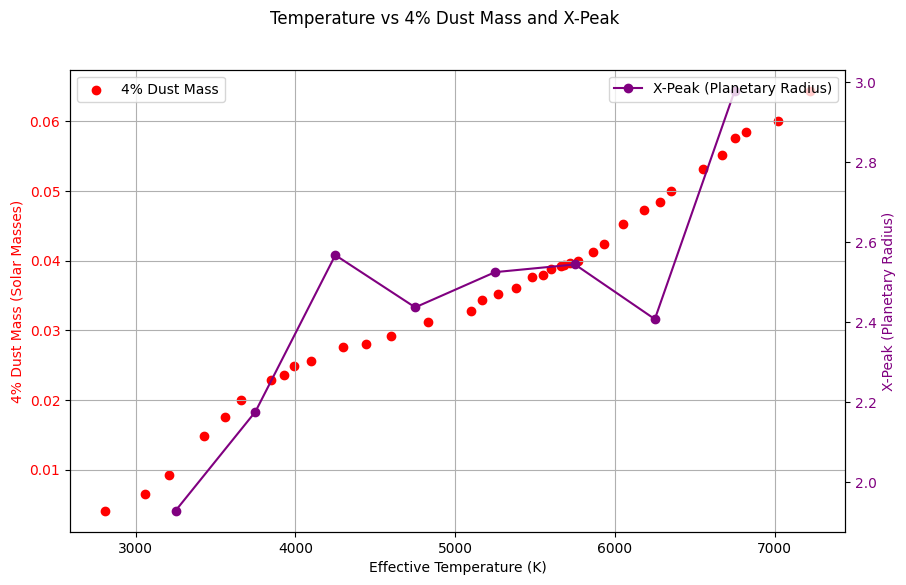

In [8]:
import pandas as pd

#1.5-4Earth RADII

data = {
   'Teff Min (K)': [3000, 3500, 4000, 4500, 5000, 5500, 6000, 6500],
   'Teff Max (K)': [3500, 4000, 4500, 5000, 5500, 6000, 6500, 7000],
   'Peak X': [1.927684, 2.175462, 2.567005, 2.436349, 2.524474, 2.543696, 2.406915, 2.978265],
   'Peak Y': [0.789187, 0.751861, 0.614592, 0.506041, 0.617798, 0.587203, 0.580212, 0.597436],
   'Average Temp': [3250.0, 3750.0, 4250.0, 4750.0, 5250.0, 5750.0, 6250.0, 6750.0]
}

df = pd.DataFrame(data)
print(df)


fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot 4% Dust Mass on the primary y-axis
ax1.scatter(stellar_df['Effective Temperature'], stellar_df['4% Dust Mass'], color='r', label='4% Dust Mass')
ax1.set_xlabel('Effective Temperature (K)')
ax1.set_ylabel('4% Dust Mass (Solar Masses)', color='r')
ax1.tick_params(axis='y', labelcolor='r')
ax1.grid(True)

# Create a secondary y-axis for Mean
ax2 = ax1.twinx()
ax2.plot(data['Average Temp'], data['Peak X'], color='purple', label='X-Peak (Planetary Radius)', marker='o', linestyle='-')
ax2.set_ylabel('X-Peak (Planetary Radius)', color='purple')
ax2.tick_params(axis='y', labelcolor='purple')

# Add a title and legend
fig.suptitle('Temperature vs 4% Dust Mass and X-Peak')
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')

plt.show()



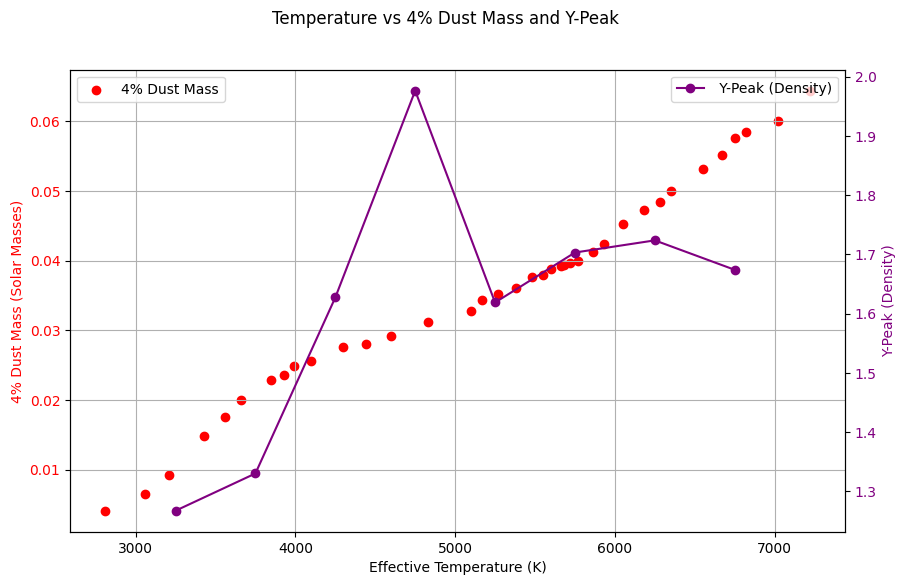

In [9]:

fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot 4% Dust Mass on the primary y-axis
ax1.scatter(stellar_df['Effective Temperature'], stellar_df['4% Dust Mass'], color='r', label='4% Dust Mass')
ax1.set_xlabel('Effective Temperature (K)')
ax1.set_ylabel('4% Dust Mass (Solar Masses)', color='r')
ax1.tick_params(axis='y', labelcolor='r')
ax1.grid(True)

# Create a secondary y-axis for Mean
ax2 = ax1.twinx()
ax2.plot(data['Average Temp'], [1/y for y in data['Peak Y']], color='purple', label=' Y-Peak (Density)', marker='o', linestyle='-')
ax2.set_ylabel('Y-Peak (Density)', color='purple')
ax2.tick_params(axis='y', labelcolor='purple')

# Add a title and legend
fig.suptitle('Temperature vs 4% Dust Mass and Y-Peak')
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')

plt.show()



Teff 3000-3500 K: N=62, Median=2.08, Error=0.086 R_Earth
Teff 3500-4000 K: N=108, Median=2.23, Error=0.057 R_Earth
Teff 4000-4500 K: N=108, Median=2.59, Error=0.081 R_Earth
Teff 4500-5000 K: N=132, Median=2.60, Error=0.081 R_Earth
Teff 5000-5500 K: N=198, Median=2.62, Error=0.049 R_Earth
Teff 5500-6000 K: N=265, Median=2.62, Error=0.057 R_Earth
Teff 6000-6500 K: N=149, Median=2.68, Error=0.084 R_Earth
Teff 6500-7000 K: N=31, Median=2.98, Error=0.132 R_Earth

Total bins: 8, 8, 8
Teff 5000-5500 K: N=198, Median=2.62, Error=0.049 R_Earth
Teff 5500-6000 K: N=265, Median=2.62, Error=0.057 R_Earth
Teff 6000-6500 K: N=149, Median=2.68, Error=0.084 R_Earth
Teff 6500-7000 K: N=31, Median=2.98, Error=0.132 R_Earth

Total bins: 8, 8, 8


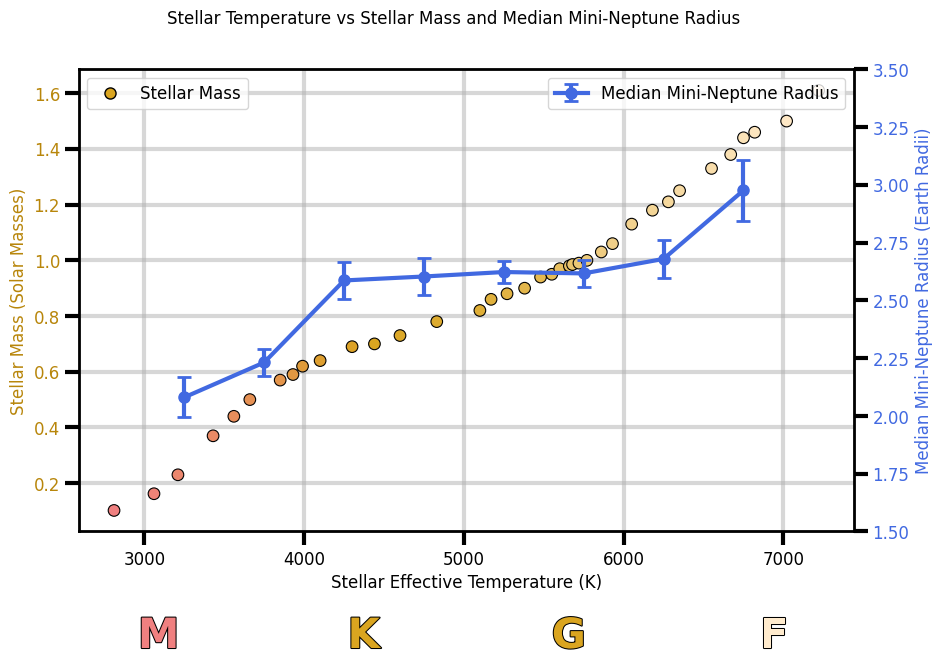

In [24]:
#### PRESENTATION VERSION ####

# Bootstrap error calculation
n_bootstrap = 1000

# Load TOI data for bootstrapping
TOIs = pd.read_csv('./TOI_Mar2025_1pt5to4_R_with_extra_columns.csv')
TOIs = TOIs.dropna(subset=['st_teff', 'pl_rade'])
TOIs = TOIs[(TOIs['pl_rade'] > 1.5) & (TOIs['pl_rade'] < 4.0)]
TOIs = TOIs[(TOIs['pl_orbper'] > 0.519) & (TOIs['pl_orbper'] < 30)]
if 'tfopwg_disp' in TOIs.columns:
    TOIs = TOIs[TOIs['tfopwg_disp'] != 'FP']

# Define temperature bins matching mean_median_df
bins_teff = [3000, 3500, 4000, 4500, 5000, 5500, 6000, 6500, 7000]

planet_radii_medians = []
planet_radii_errors = []
bin_centers = []

for i in range(len(bins_teff)-1):
    bin_mask = (TOIs['st_teff'] >= bins_teff[i]) & (TOIs['st_teff'] < bins_teff[i+1])
    planet_radii = TOIs.loc[bin_mask, 'pl_rade']
    planet_radii_n = len(planet_radii)
    
    if planet_radii_n == 0:
        planet_radii_errors.append(np.nan)
        planet_radii_medians.append(np.nan)
        bin_centers.append((bins_teff[i] + bins_teff[i+1]) / 2)
        continue
    
    # Bootstrap resampling
    bootstrap_medians = []
    for _ in range(n_bootstrap):
        bootstrap_sample = planet_radii.sample(n=planet_radii_n, replace=True)
        bootstrap_medians.append(np.median(bootstrap_sample))
    
    planet_radii_error = np.std(bootstrap_medians)
    planet_radii_median = np.median(planet_radii)
    
    print(f"Teff {bins_teff[i]}-{bins_teff[i+1]} K: N={planet_radii_n}, Median={planet_radii_median:.2f}, Error={planet_radii_error:.3f} R_Earth")
    
    planet_radii_medians.append(planet_radii_median)
    planet_radii_errors.append(planet_radii_error)
    bin_centers.append((bins_teff[i] + bins_teff[i+1]) / 2)

print(f"\nTotal bins: {len(planet_radii_medians)}, {len(planet_radii_errors)}, {len(bin_centers)}")

# Create the plot
fig, ax1 = plt.subplots(figsize=(10, 6))

import matplotlib.colors as mcolors

# Gradual color transition for scatter points
n_points = len(stellar_df)
colors = []
for i in range(n_points):
    ratio = i / (n_points - 1)
    if ratio <= 0.3:
        local_ratio = ratio / 0.3
        r = 240 + (218 - 240) * local_ratio
        g = 128 + (165 - 128) * local_ratio
        b = 128 + (32 - 128) * local_ratio
    else:
        local_ratio = (ratio - 0.3) / 0.7
        r = 218 + (255 - 218) * local_ratio
        g = 165 + (235 - 165) * local_ratio
        b = 32 + (205 - 32) * local_ratio
    colors.append((r/255, g/255, b/255))

from matplotlib.lines import Line2D
from matplotlib.patheffects import withStroke
ax1.grid(True, linewidth =3, alpha=.5, zorder=0)

legend_elements = [Line2D([0], [0], marker='o', color='w', label='Stellar Mass',
                          markerfacecolor='goldenrod', markeredgecolor='black', markersize=8, linewidth=.1)]
ax1.scatter(stellar_df['Effective Temperature'], stellar_df['Mass'], 
           c=colors, edgecolor='black', linewidth=0.8, s=70, zorder = 3)
ax1.set_xlabel('Stellar Effective Temperature (K)', size=12)
ax1.set_ylabel('Stellar Mass (Solar Masses)', color='darkgoldenrod', size=12)
ax1.tick_params(axis='y', labelcolor='darkgoldenrod')
#ax1.set_ylim(-.00,.07)

# Add colored spectral type labels to the bottom of the plot
# Add colored spectral type labels to the bottom of the plot with black outline


# Use a thinner black outline for the spectral type labels
outline = [withStroke(linewidth=1.5, foreground='black')]

xmin, xmax = ax1.get_xlim()
y_bottom = ax1.get_ylim()[0] - .3
x_positions = np.linspace(xmin + 500, xmax - 500, 4)
ax1.text(x_positions[0], y_bottom, 'M', color='lightcoral', fontsize=30, va='top', ha='center', fontweight='bold', path_effects=outline)
ax1.text(x_positions[1], y_bottom, 'K', color='goldenrod', fontsize=30, va='top', ha='center', fontweight='bold', path_effects=outline)
ax1.text(x_positions[2], y_bottom, 'G', color='goldenrod', fontsize=30, va='top', ha='center', fontweight='bold', path_effects=outline)

ax1.text(x_positions[3], y_bottom, 'F', color='blanchedalmond', fontsize=30, va='top', ha='center', fontweight='bold', path_effects=outline)

# Secondary y-axis for Median with error bars
ax2 = ax1.twinx()
ax2.errorbar(bin_centers, planet_radii_medians, yerr=planet_radii_errors,
             color='royalblue', label='Median Mini-Neptune Radius', marker='o', 
             linestyle='-', markersize=8, linewidth=3, capsize=5, capthick=2)
ax2.set_ylabel('Median Mini-Neptune Radius (Earth Radii)', color='royalblue', size=12)
ax2.tick_params(axis='y', labelcolor='royalblue', size=12)
ax2.set_ylim(1.5,3.5)
    # for spine in ax.spines.values():
    #     spine.set_linewidth(3)

fig.suptitle('Stellar Temperature vs Stellar Mass and Median Mini-Neptune Radius', size=12)
ax1.legend(handles=legend_elements, loc='upper left', fontsize=12)
ax2.legend(loc='upper right', fontsize=12)
ax1.tick_params(axis='both', which='major', width=3, length=10, labelsize=12)
ax1.tick_params(axis='both', which='minor', width=2, length=6, labelsize=12)
ax2.tick_params(axis='both', which='major', width=3, length=10, labelsize=12)
ax2.tick_params(axis='both', which='minor', width=2, length=6, labelsize=12)
for spine in ax1.spines.values():
    spine.set_linewidth(2)
plt.show()


fig.savefig('stellar_temp_vs_disk_mass_and_median_radius.png', dpi=300, bbox_inches='tight')


In [11]:
from scipy.interpolate import interp1d
import numpy as np

# Load the .txt file into a pandas DataFrame
# This isn't right

columns = ['Flux (F_oplus)', 'Mass (M_oplus)', '0.01%', '0.02%', '0.05%', '0.1%', '0.2%', '0.5%', '1%', '2%', '5%', '10%', '20%']
low_mass_planet_df = pd.read_csv('low_mass_planet_R_10GYR_solar_metallicity.txt', delim_whitespace=True, skiprows=5, names=columns)

# Plot the data
fig, ax = plt.subplots(figsize=(10, 6))

low_mass_planet_df_1000 = low_mass_planet_df[low_mass_planet_df['Flux (F_oplus)'] ==1000]
low_mass_planet_df_10 = low_mass_planet_df[low_mass_planet_df['Flux (F_oplus)'] ==10]
low_mass_planet_df_pt1 = low_mass_planet_df[low_mass_planet_df['Flux (F_oplus)'] ==.1]

for column in columns[2:]:
    ax.scatter(low_mass_planet_df_1000['Mass (M_oplus)'], low_mass_planet_df_1000[column], label=column)

ax.set_xlabel('Mass (M_earth)')
ax.set_ylabel('Radius (R_earth)')
ax.set_title('Radius vs Mass for Different Hydrogen Fractions')
ax.legend(title='Hydrogen Fraction', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(True)
ax.set_ylim(1.5,4)

plt.show()



FileNotFoundError: [Errno 2] No such file or directory: 'low_mass_planet_R_10GYR_solar_metallicity.txt'

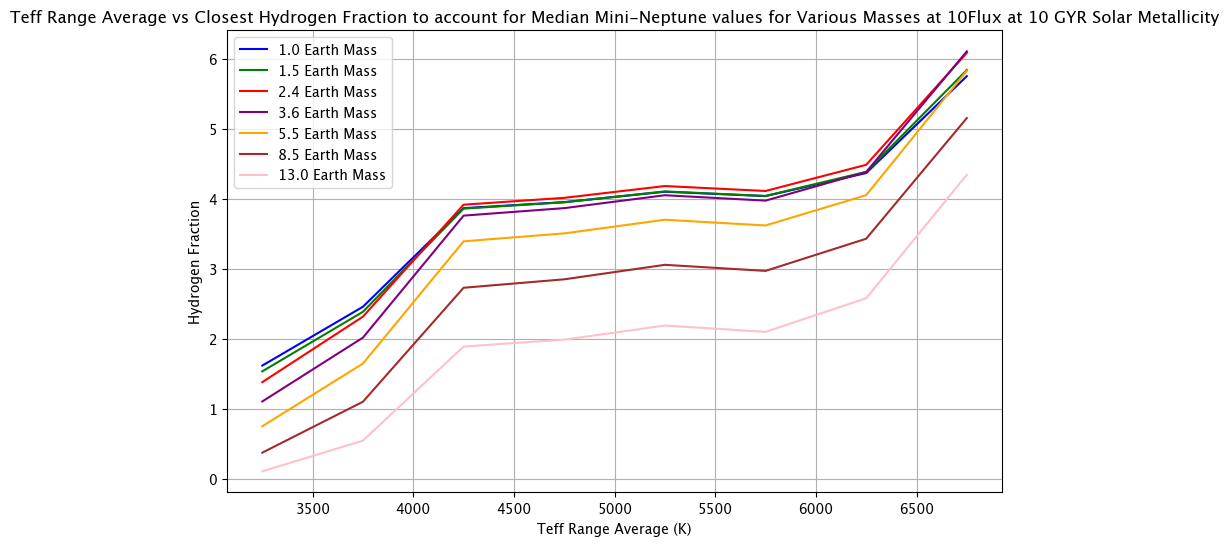

In [ ]:
#interp for 5.5M_earth


#print(low_mass_planet_df_10)
mass_held_values = [1.0, 1.5, 2.4, 3.6, 5.5, 8.5, 13.0]  # List of mass held values
colors = ['blue', 'green', 'red', 'purple', 'orange', 'brown', 'pink', 'cyan']  # Colors for each line

plt.figure(figsize=(10, 6))

for mass_held, color in zip(mass_held_values, colors):
    mass_5M_values = low_mass_planet_df_10.loc[low_mass_planet_df_10['Mass (M_oplus)'] == mass_held].iloc[0, 2:].values

    #interp function
    interp_func = interp1d(mass_5M_values, hydrogen_values, kind='linear')

    mass_interpolated = np.linspace(mass_5M_values.min(), mass_5M_values.max(), len(mass_5M_values) * 10)
    hydrogen_interpolated = interp_func(mass_interpolated)

    plt.plot(mean_median_df['Teff Range Average'], mean_median_df['Median'].apply(
        lambda median: interp1d(mass_interpolated, hydrogen_interpolated, kind='linear')(median)),
        label=f'{mass_held} Earth Mass', color=color)

plt.xlabel('Teff Range Average (K)')
plt.ylabel('Hydrogen Fraction')
plt.title('Teff Range Average vs Closest Hydrogen Fraction to account for Median Mini-Neptune values for Various Masses at 10Flux at 10 GYR Solar Metallicity')
plt.legend()
plt.grid(True)
plt.show()


    Mass (M_oplus)  2% (Interpolated)
0         1.000000           2.170000
1         1.240506           2.179620
2         1.481013           2.189241
3         1.721519           2.194923
4         1.962025           2.200267
..             ...                ...
75       19.037975           2.748011
76       19.278481           2.753508
77       19.518987           2.759005
78       19.759494           2.764503
79       20.000000           2.770000

[80 rows x 2 columns]
   Teff Range      Mean    Median  Teff Range Average  median_2%_10F_mass
0  3000-3500K  2.231836  2.055025              3250.0            1.000000
1  3500-4000K  2.383887  2.272141              3750.0            3.645570
2  4000-4500K  2.615846  2.586557              4250.0           12.303797
3  4500-5000K  2.627477  2.605837              4750.0           12.784810
4  5000-5500K  2.705931  2.638960              5250.0           14.227848
5  5500-6000K  2.665147  2.625087              5750.0           13.746835
6  

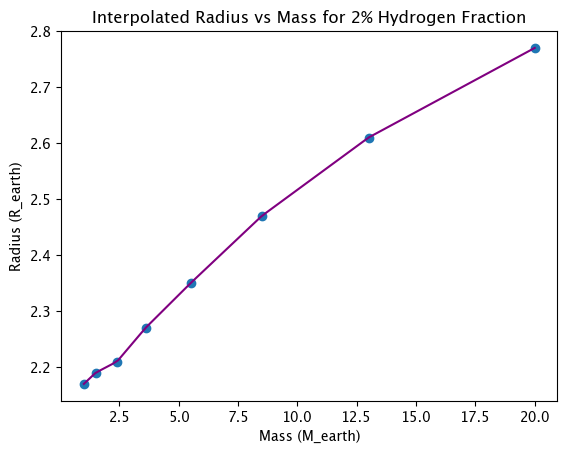

In [ ]:
#interp for 2% Flux 10

hydrogen_values = low_mass_planet_df_10['Mass (M_oplus)']
radius_values = low_mass_planet_df_10['2%']

# Create interpolation function
interp_func = interp1d(mass_values, radius_values, kind='linear')

# Generate x10 points
mass_interpolated = np.linspace(mass_values.min(), mass_values.max(), len(mass_values) * 10)
radius_interpolated = interp_func(mass_interpolated)

# Create a new DataFrame with interpolated values
interpolated_df = pd.DataFrame({
    'Mass (M_oplus)': mass_interpolated,
    '2% (Interpolated)': radius_interpolated
})

print(interpolated_df)

plt.plot(interpolated_df['Mass (M_oplus)'], interpolated_df['2% (Interpolated)'], label='2% Interpolated', color='purple')
plt.scatter(mass_values, radius_values)
plt.xlabel('Mass (M_earth)')
plt.ylabel('Radius (R_earth)')
plt.title('Interpolated Radius vs Mass for 2% Hydrogen Fraction')

# Find the closest corresponding mass for each median value in mean_median_df
mean_median_df['median_2%_10F_mass'] = mean_median_df['Median'].apply(
    lambda median: interpolated_df.iloc[(interpolated_df['2% (Interpolated)'] - median).abs().idxmin()]['Mass (M_oplus)']
)

print(mean_median_df)

#plt.plot(mean_median_df['median_2%_10F_mass'], mean_median_df['Median'], label='Median', color='g', marker='o', linestyle='-')

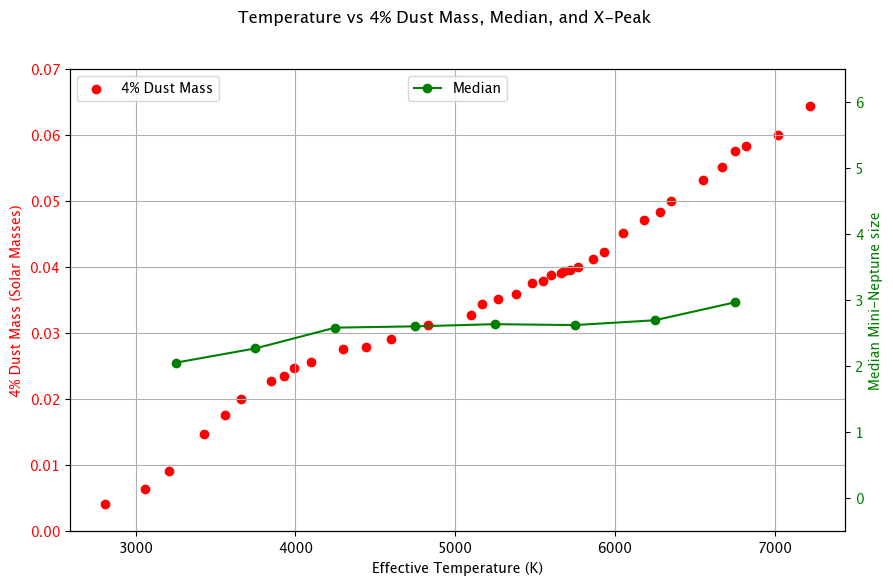

In [ ]:
fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot 4% Dust Mass on the primary y-axis
ax1.scatter(stellar_df['Effective Temperature'], stellar_df['4% Dust Mass'], color='r', label='4% Dust Mass')
ax1.set_xlabel('Effective Temperature (K)')
ax1.set_ylabel('4% Dust Mass (Solar Masses)', color='r')
ax1.tick_params(axis='y', labelcolor='r')
ax1.grid(True)
ax1.set_ylim(-.00, .07)

# Create a secondary y-axis for Median
ax2 = ax1.twinx()
ax2.plot(mean_median_df['Teff Range Average'], mean_median_df['Median'], color='g', label='Median', marker='o', linestyle='-')
ax2.set_ylabel('Median Mini-Neptune size', color='g')
ax2.tick_params(axis='y', labelcolor='g')
ax2.set_ylim(-.5, 6.5)

# # Create a third y-axis
# ax3 = ax1.twinx()
# ax3.spines['right'].set_position(('outward', 60))  # Offset the third axis
# ax3.plot(mean_median_df['Teff Range Average'], mean_median_df['median_2%_10F_mass'], color='b', label='0.2% Hydrogen Fraction Mass', marker='o', linestyle='-')
# ax3.set_ylabel('Planetary Mass Hydrogen fraction .2', color='b')
# ax3.tick_params(axis='y', labelcolor='b')
# #ax3.set_ylim(1, 4)


# Add a title and legends
fig.suptitle('Temperature vs 4% Dust Mass, Median, and X-Peak')
ax1.legend(loc='upper left')
ax2.legend(loc='upper center')
ax3.legend(loc='upper right')

plt.show()